### Single-Channel LeNet Style

| Layer | Operation | Output Size |
| :--- | :--- | :--- |
| **Input** | Input Grayscale Image | 32×32×1 |
| **Conv1** | 5×5, 6 filters | 28×28×6 |
| **Pool1** | 2×2 | 14×14×6 |
| **Conv2** | 5×5, 16 filters | 10×10×16 |
| **Pool2** | 2×2 | 5×5×16 |
| **Flatten** | Flatten | 400 |
| **FC1** | Fully Connected | 120 |
| **FC2** | Output Layer | 10 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X_gray = np.array([
    [1, 2, 0, 1, 3, 1],
    [4, 1, 1, 2, 0, 0],
    [0, 1, 3, 1, 1, 2],
    [2, 2, 0, 1, 4, 1],
    [1, 0, 1, 3, 1, 0],
    [2, 1, 2, 1, 0, 1]
], dtype=float)

print("X_gray.shape =", X_gray.shape)
print(X_gray)

X_gray.shape = (6, 6)
[[1. 2. 0. 1. 3. 1.]
 [4. 1. 1. 2. 0. 0.]
 [0. 1. 3. 1. 1. 2.]
 [2. 2. 0. 1. 4. 1.]
 [1. 0. 1. 3. 1. 0.]
 [2. 1. 2. 1. 0. 1.]]


In [3]:
def pad2d(x, pad=1):
    """
    给二维矩阵 x 四周补 0
    x: shape = (H, W)
    pad: 补几圈 0
    """
    H, W = x.shape
    out = np.zeros((H + 2*pad, W + 2*pad))
    out[pad:pad+H, pad:pad+W] = x
    return out

In [4]:
x_small = np.array([
    [1, 2],
    [3, 4]
], dtype=float)

x_pad = pad2d(x_small, pad=1)

print("原矩阵:")
print(x_small)
print("\npadding 后:")
print(x_pad)
print("\nshape:", x_small.shape, "->", x_pad.shape)

原矩阵:
[[1. 2.]
 [3. 4.]]

padding 后:
[[0. 0. 0. 0.]
 [0. 1. 2. 0.]
 [0. 3. 4. 0.]
 [0. 0. 0. 0.]]

shape: (2, 2) -> (4, 4)


### Convolutional Output Size

$$H_{out} = \frac{H_{in} - K + 2P}{S} + 1$$

$$W_{out} = \frac{W_{in} - K + 2P}{S} + 1$$

* **$H_{in} / W_{in}$**: Input Height / Width
* **$K$**: Kernel (Filter) Size
* **$P$**: Padding
* **$S$**: Stride
* **$H_{out} / W_{out}$**: Output Height / Width

In [5]:
def conv2d_single(x, kernel, stride=1, pad=0):
    """
    单通道二维卷积
    x: 输入图像, shape=(H, W)
    kernel: 卷积核, shape=(Kh, Kw)
    stride: 步长
    pad: padding 大小
    """
    if pad > 0:
        x = pad2d(x, pad)

    H, W = x.shape
    Kh, Kw = kernel.shape

    out_h = (H - Kh) // stride + 1
    out_w = (W - Kw) // stride + 1
    out = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            h_end = h_start + Kh
            w_start = j * stride
            w_end = w_start + Kw

            region = x[h_start:h_end, w_start:w_end]
            out[i, j] = np.sum(region * kernel)

    return out

In [6]:
kernel_edge = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=float)

conv_out = conv2d_single(X_gray, kernel_edge, stride=1, pad=0)

print("输入 shape:", X_gray.shape)
print("卷积核 shape:", kernel_edge.shape)
print("输出 shape:", conv_out.shape)
print(conv_out)

输入 shape: (6, 6)
卷积核 shape: (3, 3)
输出 shape: (4, 4)
[[ 1.  0.  0.  1.]
 [ 2.  0. -1.  1.]
 [-1. -2. -2.  2.]
 [ 2. -2. -2.  3.]]


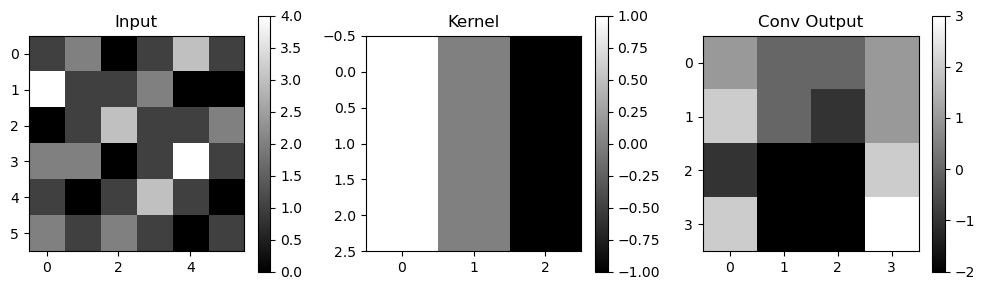

In [7]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.imshow(X_gray, cmap="gray")
plt.title("Input")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(kernel_edge, cmap="gray")
plt.title("Kernel")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(conv_out, cmap="gray")
plt.title("Conv Output")
plt.colorbar()

plt.tight_layout()
plt.show()

In [8]:
def relu(x):
    return np.maximum(0, x)

In [9]:
x_test = np.array([
    [-2, -1, 0],
    [1, 2, -3]
], dtype=float)

relu_out = relu(x_test)

print("输入:")
print(x_test)
print("\nReLU 后:")
print(relu_out)

输入:
[[-2. -1.  0.]
 [ 1.  2. -3.]]

ReLU 后:
[[0. 0. 0.]
 [1. 2. 0.]]


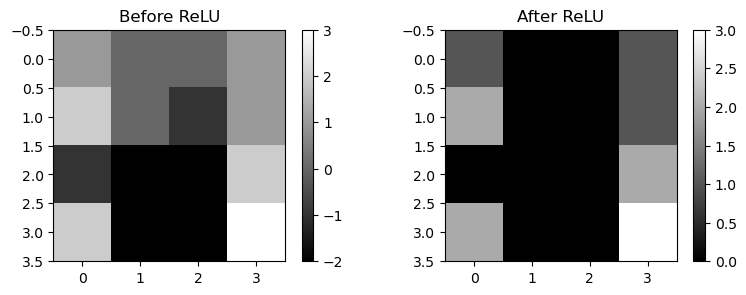

In [10]:
conv_relu = relu(conv_out)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(conv_out, cmap="gray")
plt.title("Before ReLU")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(conv_relu, cmap="gray")
plt.title("After ReLU")
plt.colorbar()

plt.tight_layout()
plt.show()

In [11]:
def maxpool2d(x, pool_size=2, stride=2):
    """
    二维最大池化
    x: shape=(H, W)
    pool_size: 池化窗口大小
    stride: 步长
    """
    H, W = x.shape
    out_h = (H - pool_size) // stride + 1
    out_w = (W - pool_size) // stride + 1

    out = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            h_end = h_start + pool_size
            w_start = j * stride
            w_end = w_start + pool_size

            region = x[h_start:h_end, w_start:w_end]
            out[i, j] = np.max(region)

    return out

In [12]:
x_pool_test = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 1, 3],
    [1, 2, 4, 0]
], dtype=float)

pool_out = maxpool2d(x_pool_test, pool_size=2, stride=2)

print("输入:")
print(x_pool_test)
print("\n池化后:")
print(pool_out)
print("\nshape:", x_pool_test.shape, "->", pool_out.shape)

输入:
[[1. 3. 2. 0.]
 [4. 6. 5. 1.]
 [0. 2. 1. 3.]
 [1. 2. 4. 0.]]

池化后:
[[6. 5.]
 [2. 4.]]

shape: (4, 4) -> (2, 2)


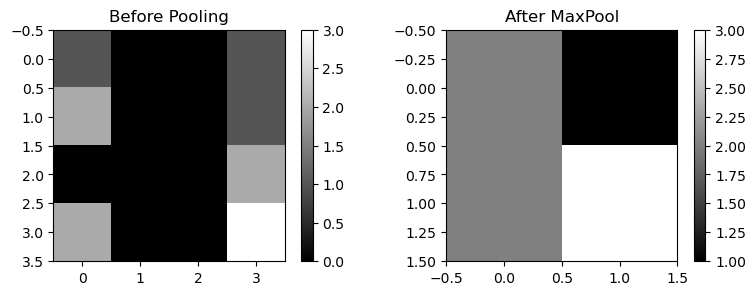

In [13]:
pooled = maxpool2d(conv_relu, pool_size=2, stride=2)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(conv_relu, cmap="gray")
plt.title("Before Pooling")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(pooled, cmap="gray")
plt.title("After MaxPool")
plt.colorbar()

plt.tight_layout()
plt.show()

In [14]:
def flatten(x):
    return x.reshape(-1)

In [15]:
x_flat_test = np.array([
    [1, 2],
    [3, 4]
], dtype=float)

flat_out = flatten(x_flat_test)

print("原矩阵:")
print(x_flat_test)
print("shape:", x_flat_test.shape)

print("\n展平后:")
print(flat_out)
print("shape:", flat_out.shape)

原矩阵:
[[1. 2.]
 [3. 4.]]
shape: (2, 2)

展平后:
[1. 2. 3. 4.]
shape: (4,)


In [16]:
flat_feature = flatten(pooled)

print("池化输出 shape:", pooled.shape)
print("展平后 shape:", flat_feature.shape)
print(flat_feature)

池化输出 shape: (2, 2)
展平后 shape: (4,)
[2. 1. 2. 3.]


In [17]:
def linear(x, W, b):
    """
    全连接层
    x: shape=(in_features,)
    W: shape=(out_features, in_features)
    b: shape=(out_features,)
    """
    return W @ x + b

In [18]:
x_fc = np.array([1.0, 2.0, 3.0, 4.0])

W_fc = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.9, 1.0, 1.1, 1.2]
])

b_fc = np.array([0.1, 0.2, 0.3])

fc_out = linear(x_fc, W_fc, b_fc)

print("输入 x =", x_fc)
print("输出 y =", fc_out)

输入 x = [1. 2. 3. 4.]
输出 y = [ 3.1  7.2 11.3]


In [19]:
def softmax(x):
    x = x - np.max(x)   # 数值稳定
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [20]:
scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)

print("原始分数:", scores)
print("softmax 概率:", probs)
print("概率和:", np.sum(probs))

原始分数: [2.  1.  0.1]
softmax 概率: [0.65900114 0.24243297 0.09856589]
概率和: 1.0


In [21]:
def simple_cnn_forward(x, kernel, W, b):
    # 1) 卷积
    z1 = conv2d_single(x, kernel, stride=1, pad=0)
    
    # 2) ReLU
    a1 = relu(z1)
    
    # 3) Pooling
    p1 = maxpool2d(a1, pool_size=2, stride=2)
    
    # 4) Flatten
    f1 = flatten(p1)
    
    # 5) FC
    z2 = linear(f1, W, b)
    
    # 6) Softmax
    y_hat = softmax(z2)
    
    return {
        "conv": z1,
        "relu": a1,
        "pool": p1,
        "flat": f1,
        "fc": z2,
        "prob": y_hat
    }

In [22]:
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=float)

W = np.array([
    [0.2, -0.1, 0.3, 0.5],
    [-0.4, 0.2, 0.1, -0.2]
], dtype=float)   # 输出2类

b = np.array([0.1, -0.1], dtype=float)

result = simple_cnn_forward(X_gray, kernel, W, b)

for k, v in result.items():
    print(f"\n{k}:")
    print(v)
    if isinstance(v, np.ndarray):
        print("shape =", v.shape)


conv:
[[ 1.  0.  0.  1.]
 [ 2.  0. -1.  1.]
 [-1. -2. -2.  2.]
 [ 2. -2. -2.  3.]]
shape = (4, 4)

relu:
[[1. 0. 0. 1.]
 [2. 0. 0. 1.]
 [0. 0. 0. 2.]
 [2. 0. 0. 3.]]
shape = (4, 4)

pool:
[[2. 1.]
 [2. 3.]]
shape = (2, 2)

flat:
[2. 1. 2. 3.]
shape = (4,)

fc:
[ 2.5 -1.1]
shape = (2,)

prob:
[0.97340301 0.02659699]
shape = (2,)


### Multi-channel RGB CNN

| Layer | Operation | Output Size |
| :--- | :--- | :--- |
| **Input** | Input Color Image | 32×32×3 |
| **Conv1** | 3×3×3, 8 filters | 30×30×8 |
| **Padding** | p=1 | 32×32×8 |
| **Pool1** | 2×2 | 16×16×8 |
| **Conv2** | 3×3×8, 16 filters | 14×14×16 |
| **Pool2** | 2×2 | 7×7×16 |
| **Flatten** | Flatten | 784 |
| **FC** | Classification | C |

In [33]:
def pad3d(x, pad=1):
    """
    对 3D 输入做 padding
    x: (H, W, C)
    """
    H, W, C = x.shape
    out = np.zeros((H + 2*pad, W + 2*pad, C))
    out[pad:pad+H, pad:pad+W, :] = x
    return out

In [32]:
def maxpool2d_multi(x, pool_size=2, stride=2):
    """
    多通道最大池化
    x: (H, W, C)
    return: (H_out, W_out, C)
    """
    H, W, C = x.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    out = np.zeros((H_out, W_out, C))

    for c in range(C):
        for i in range(H_out):
            for j in range(W_out):
                hs = i * stride
                ws = j * stride
                region = x[hs:hs+pool_size, ws:ws+pool_size, c]
                out[i, j, c] = np.max(region)

    return out

In [23]:
def conv2d_multi_channel(x, kernel, stride=1, pad=0):
    """
    多通道卷积
    x: shape=(H, W, C_in)
    kernel: shape=(Kh, Kw, C_in)
    输出: shape=(H_out, W_out)
    """
    H, W, C = x.shape
    Kh, Kw, Ck = kernel.shape

    assert C == Ck, "输入通道数必须等于卷积核通道数"

    if pad > 0:
        x_pad = np.zeros((H + 2*pad, W + 2*pad, C))
        x_pad[pad:pad+H, pad:pad+W, :] = x
        x = x_pad

    H, W, C = x.shape

    out_h = (H - Kh) // stride + 1
    out_w = (W - Kw) // stride + 1
    out = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            h_end = h_start + Kh
            w_start = j * stride
            w_end = w_start + Kw

            region = x[h_start:h_end, w_start:w_end, :]
            out[i, j] = np.sum(region * kernel)

    return out

In [25]:
X_rgb = np.random.randint(0, 5, size=(6, 6, 3)).astype(float)

print("X_rgb.shape =", X_rgb.shape)
print("第一个像素的 RGB =", X_rgb[0, 0, :])

X_rgb.shape = (6, 6, 3)
第一个像素的 RGB = [4. 0. 4.]


In [26]:
kernel_rgb = np.array([
    [[1, 0, -1], [0, 1, 0], [1, 0, -1]],
    [[1, 1, 0], [0, 0, 1], [1, -1, 0]],
    [[0, 1, 1], [1, 0, 0], [-1, 1, 0]]
], dtype=float)

rgb_conv_out = conv2d_multi_channel(X_rgb, kernel_rgb, stride=1, pad=0)

print("输入 shape:", X_rgb.shape)
print("卷积核 shape:", kernel_rgb.shape)
print("输出 shape:", rgb_conv_out.shape)
print(rgb_conv_out)

输入 shape: (6, 6, 3)
卷积核 shape: (3, 3, 3)
输出 shape: (4, 4)
[[ 7. 13. 21. 12.]
 [14. 11. 12. 14.]
 [19.  9. 26.  9.]
 [16. 19.  7.  8.]]


In [27]:
def conv2d_multi_filters(x, kernels, stride=1, pad=0):
    """
    多通道输入 + 多个卷积核
    x: shape=(H, W, C_in)
    kernels: shape=(N_filters, Kh, Kw, C_in)
    返回: shape=(H_out, W_out, N_filters)
    """
    n_filters = kernels.shape[0]
    outputs = []

    for k in range(n_filters):
        feature_map = conv2d_multi_channel(x, kernels[k], stride=stride, pad=pad)
        outputs.append(feature_map)

    return np.stack(outputs, axis=-1)

In [28]:
kernels = np.random.randn(2, 3, 3, 3)   # 2个 3×3×3 卷积核
multi_out = conv2d_multi_filters(X_rgb, kernels, stride=1, pad=0)

print("输出 shape =", multi_out.shape)

输出 shape = (4, 4, 2)


In [29]:
def two_layer_nn(x, W1, b1, W2, b2):
    """
    两层神经网络
    x: 输入向量
    W1, b1: 第一层参数
    W2, b2: 第二层参数
    """
    h = relu(W1 @ x + b1)
    y = softmax(W2 @ h + b2)
    return h, y

In [30]:
x = np.array([1.0, 2.0, 3.0, 4.0])

W1 = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.2, 0.1, 0.4, 0.3]
])
b1 = np.array([0.1, 0.2, 0.3])

W2 = np.array([
    [0.1, 0.2, 0.3],
    [0.4, 0.5, 0.6]
])
b2 = np.array([0.1, -0.1])

h, y = two_layer_nn(x, W1, b1, W2, b2)

print("隐藏层输出 h =", h)
print("最终概率 y =", y)

隐藏层输出 h = [3.1 7.2 3.1]
最终概率 y = [0.02145729 0.97854271]


In [34]:
def multi_cnn_forward(x, kernels, W, b,
                      conv_stride=1, conv_pad=0,
                      pool_size=2, pool_stride=2):
    """
    多通道 CNN 前向传播

    x:       输入图像, shape = (H, W, C_in)
    kernels: 卷积核,   shape = (N_filters, Kh, Kw, C_in)
    W:       全连接权重, shape = (N_classes, flat_dim)
    b:       全连接偏置, shape = (N_classes,)
    """
    # 1) 卷积
    z1 = conv2d_multi_filters(x, kernels, stride=conv_stride, pad=conv_pad)

    # 2) 激活
    a1 = relu(z1)

    # 3) 池化
    p1 = maxpool2d_multi(a1, pool_size=pool_size, stride=pool_stride)

    # 4) 展平
    f1 = flatten(p1)

    # 5) 全连接
    z2 = linear(f1, W, b)

    # 6) softmax
    y_hat = softmax(z2)

    return {
        "conv": z1,
        "relu": a1,
        "pool": p1,
        "flat": f1,
        "fc": z2,
        "prob": y_hat
    }

In [35]:
X = np.array([
    [[4,1,0],[9,2,1],[2,0,2],[5,1,0],[8,2,1],[3,0,2]],
    [[5,0,1],[6,1,0],[2,2,1],[4,0,2],[0,1,1],[3,2,0]],
    [[2,1,2],[4,2,1],[5,0,0],[4,1,1],[5,2,2],[2,0,1]],
    [[5,2,1],[6,1,0],[5,2,1],[4,0,2],[7,1,0],[8,2,1]],
    [[5,0,2],[7,1,1],[7,2,0],[9,1,2],[2,0,1],[1,1,0]],
    [[5,1,0],[8,2,1],[5,0,2],[3,1,1],[8,2,0],[4,0,1]],
], dtype=float)

print(X.shape)   # (6, 6, 3)

(6, 6, 3)


In [36]:
kernel1 = np.array([
    [[ 1, 0,-1],[ 0, 1, 0],[ 1, 0,-1]],
    [[ 1, 0,-1],[ 0, 1, 0],[ 1, 0,-1]],
    [[ 1, 0,-1],[ 0, 1, 0],[ 1, 0,-1]],
], dtype=float)

kernel2 = np.array([
    [[ 0, 0, 0],[ 1, 0,-1],[ 0, 0, 0]],
    [[ 1, 1, 1],[ 0, 0, 0],[-1,-1,-1]],
    [[-1, 0, 1],[ 0, 1, 0],[ 1, 0,-1]],
], dtype=float)

kernels = np.stack([kernel1, kernel2], axis=0)

print(kernels.shape)   # (2, 3, 3, 3)

(2, 3, 3, 3)


In [37]:
conv_out = conv2d_multi_filters(X, kernels, stride=1, pad=0)

print("conv_out.shape =", conv_out.shape)
print(conv_out[:, :, 0])  # 第1张特征图
print(conv_out[:, :, 1])  # 第2张特征图

conv_out.shape = (4, 4, 2)
[[19. 29. 17. 20.]
 [22. 26. 20. 22.]
 [27. 31. 29. 24.]
 [30. 34. 32. 25.]]
[[16.  1.  7.  8.]
 [ 7.  0.  1.  8.]
 [ 8.  9. -2. -8.]
 [ 4. -4. 14. 20.]]


In [38]:
# 先试运行一下，得到 flatten 长度
tmp = conv2d_multi_filters(X, kernels)
tmp = relu(tmp)
tmp = maxpool2d_multi(tmp, pool_size=2, stride=2)
flat_dim = tmp.size

print("flat_dim =", flat_dim)   # 应该是 8

# 2分类
W = np.array([
    np.linspace(0.10, 0.10 + 0.02*(flat_dim-1), flat_dim),
    np.linspace(-0.20, -0.20 + 0.015*(flat_dim-1), flat_dim),
])

b = np.array([0.1, -0.1])

result = multi_cnn_forward(X, kernels, W, b)

for k, v in result.items():
    print(f"\n{k}:")
    print(v)
    if isinstance(v, np.ndarray):
        print("shape =", v.shape)

flat_dim = 8

conv:
[[[19. 16.]
  [29.  1.]
  [17.  7.]
  [20.  8.]]

 [[22.  7.]
  [26.  0.]
  [20.  1.]
  [22.  8.]]

 [[27.  8.]
  [31.  9.]
  [29. -2.]
  [24. -8.]]

 [[30.  4.]
  [34. -4.]
  [32. 14.]
  [25. 20.]]]
shape = (4, 4, 2)

relu:
[[[19. 16.]
  [29.  1.]
  [17.  7.]
  [20.  8.]]

 [[22.  7.]
  [26.  0.]
  [20.  1.]
  [22.  8.]]

 [[27.  8.]
  [31.  9.]
  [29.  0.]
  [24.  0.]]

 [[30.  4.]
  [34.  0.]
  [32. 14.]
  [25. 20.]]]
shape = (4, 4, 2)

pool:
[[[29. 16.]
  [22.  8.]]

 [[34.  9.]
  [32. 20.]]]
shape = (2, 2, 2)

flat:
[29. 16. 22.  8. 34.  9. 32. 20.]
shape = (8,)

fc:
[ 29.04  -25.145]
shape = (2,)

prob:
[1.00000000e+00 2.93598274e-24]
shape = (2,)


In [39]:
# Step 1: 输入
print("Input shape:", X.shape)   # (6, 6, 3)

# Step 2: 卷积
z1 = conv2d_multi_filters(X, kernels)
print("After conv:", z1.shape)   # (4, 4, 2)

# Step 3: ReLU
a1 = relu(z1)
print("After relu:", a1.shape)   # (4, 4, 2)

# Step 4: Pooling
p1 = maxpool2d_multi(a1, pool_size=2, stride=2)
print("After pool:", p1.shape)   # (2, 2, 2)

# Step 5: Flatten
f1 = flatten(p1)
print("After flatten:", f1.shape)  # (8,)

# Step 6: FC + Softmax
z2 = linear(f1, W, b)
prob = softmax(z2)
print("Class scores:", z2)
print("Probabilities:", prob)

Input shape: (6, 6, 3)
After conv: (4, 4, 2)
After relu: (4, 4, 2)
After pool: (2, 2, 2)
After flatten: (8,)
Class scores: [ 29.04  -25.145]
Probabilities: [1.00000000e+00 2.93598274e-24]
